#### P2-01
#### 01_data_quality
# EDA 1
#### M4

### Data issues found
* Missing values
* Contains 31994 duplicate rows
* Contains 180 Zero guest bookings
* Contains 715 Zero day stay bookings
* Contains 220 children only bookings (Children unaccompanied by adults)
* Contains outliers in many attributes
* Many attributes are skewed

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import duckdb

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("s3://y3s1-ml-datasets/raw/hotel_bookings.csv")

/opt/venv/lib/python3.11/site-packages/fsspec/registry.py:305: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.shape

(119390, 32)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
column_names = df.columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

## Basic EDA

### Missing values

In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### Duplicates

In [9]:
dup_cnt = df.duplicated().sum()
print(dup_cnt)

31994


In [10]:
print(f"Duplicate percentage: {dup_cnt/df.shape[0] * 100}%")

Duplicate percentage: 26.797889270458164%


### Data distribution

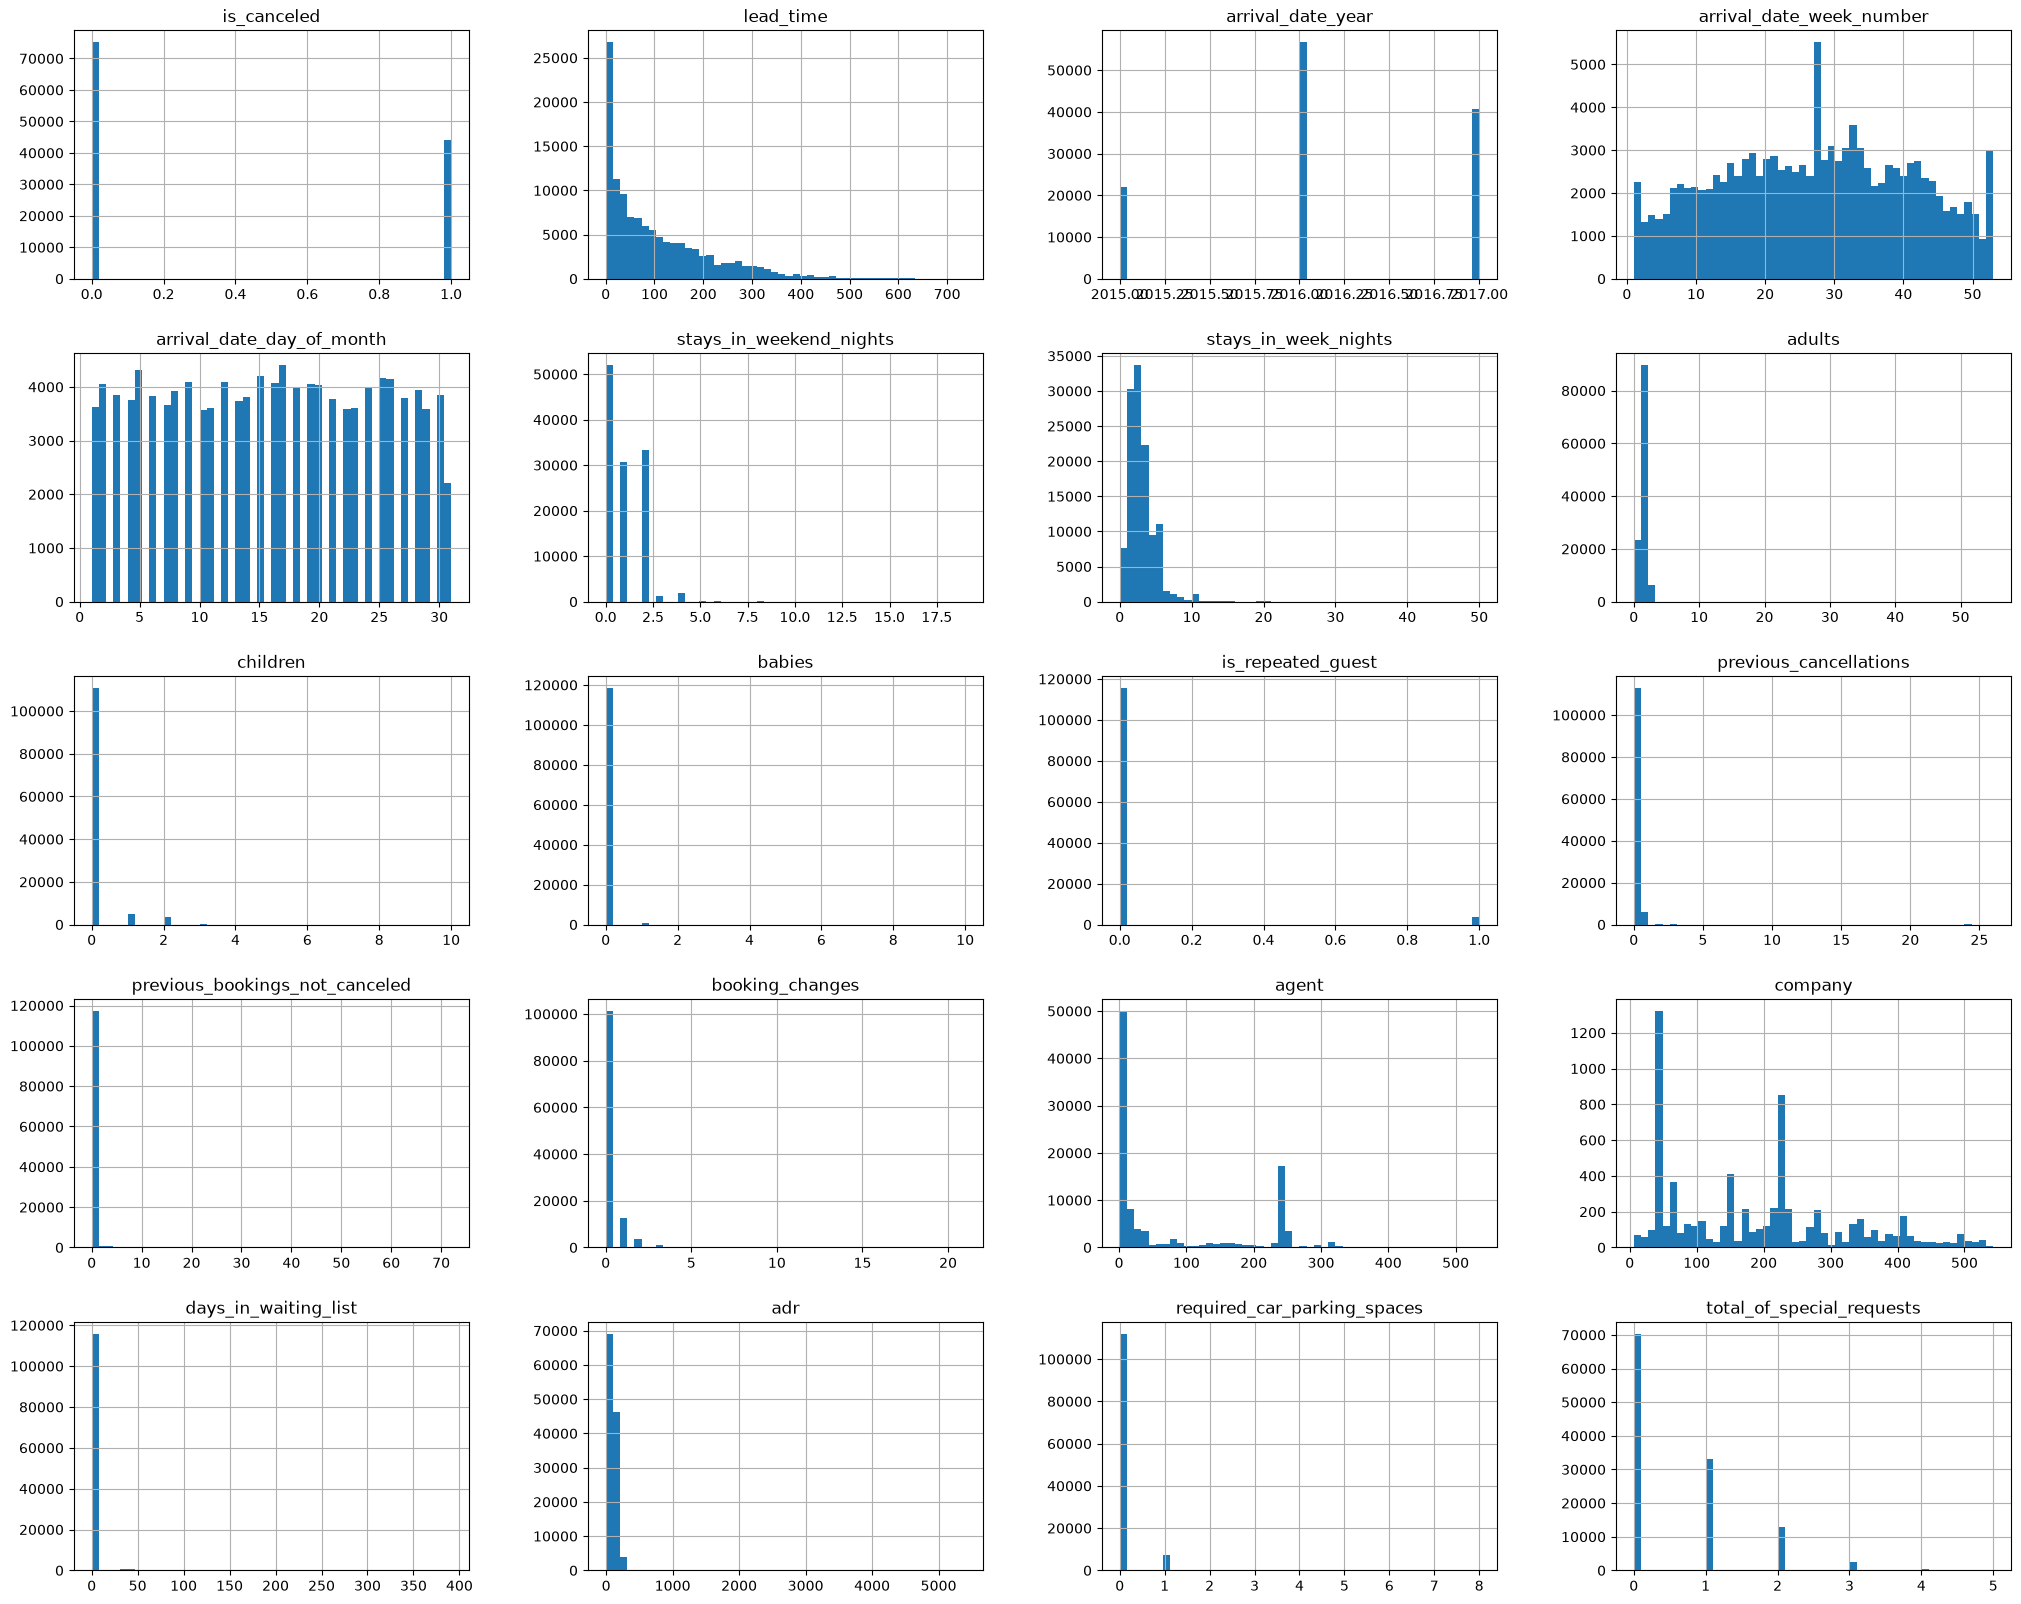

In [11]:
df.hist(bins=50, figsize=(25, 20))
plt.show()

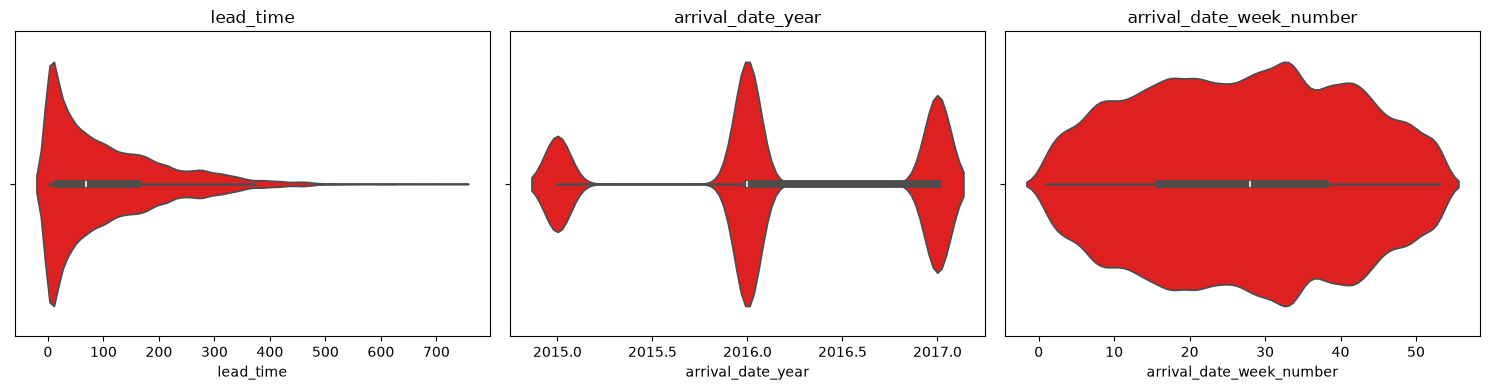

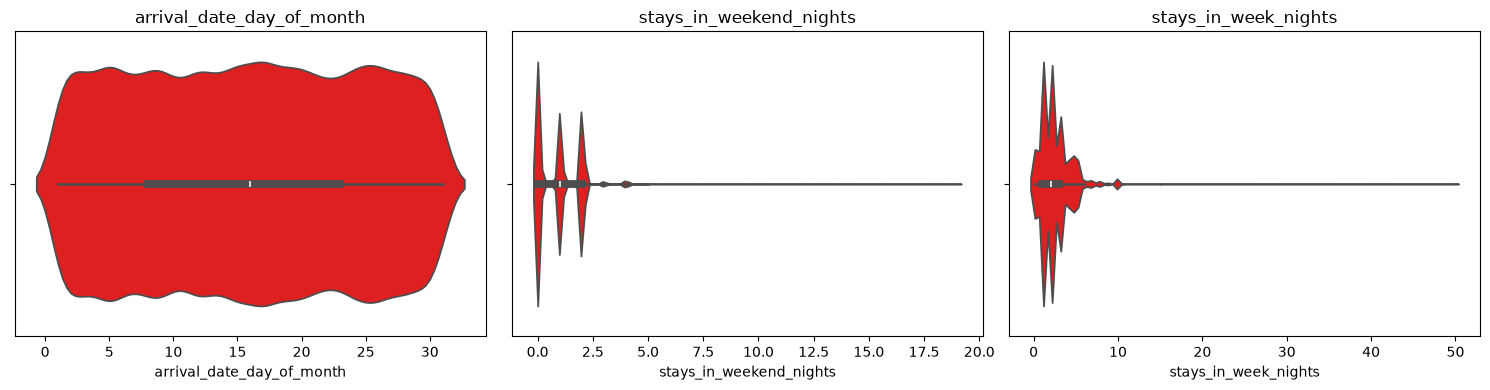

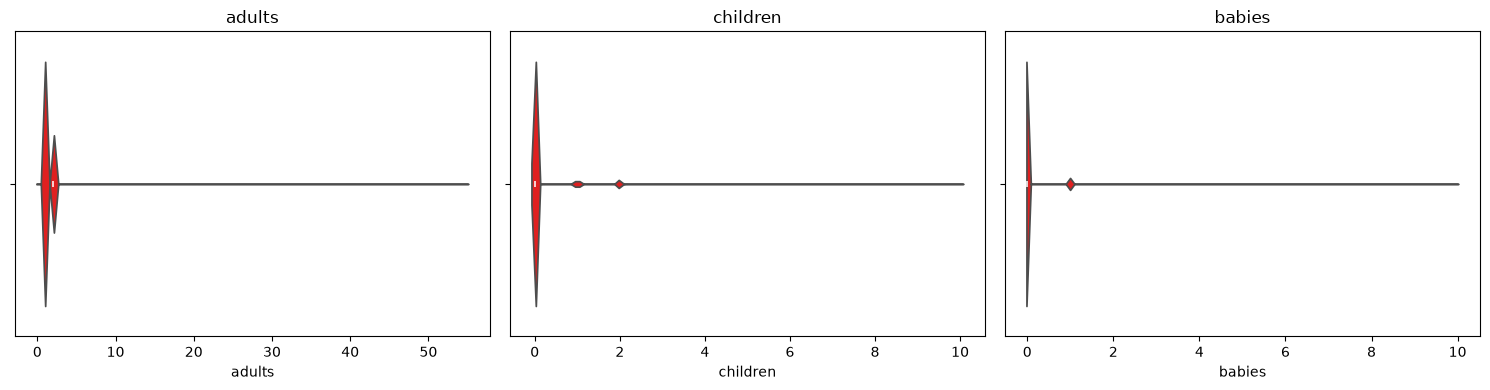

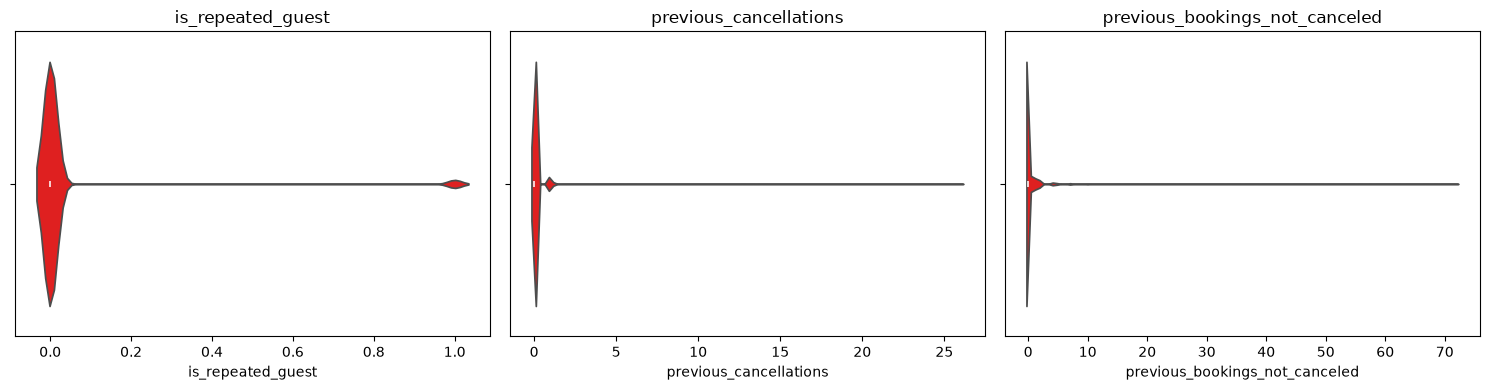

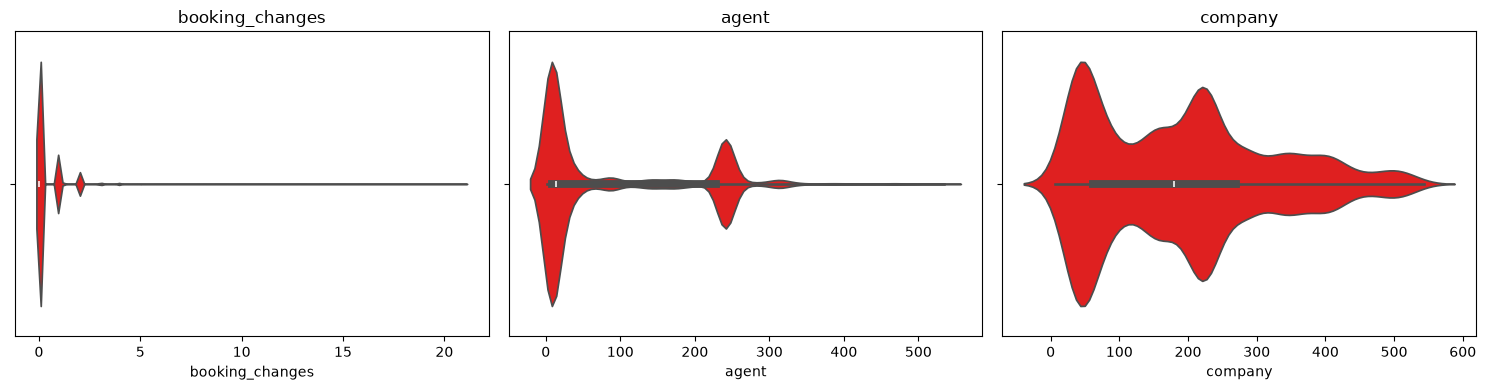

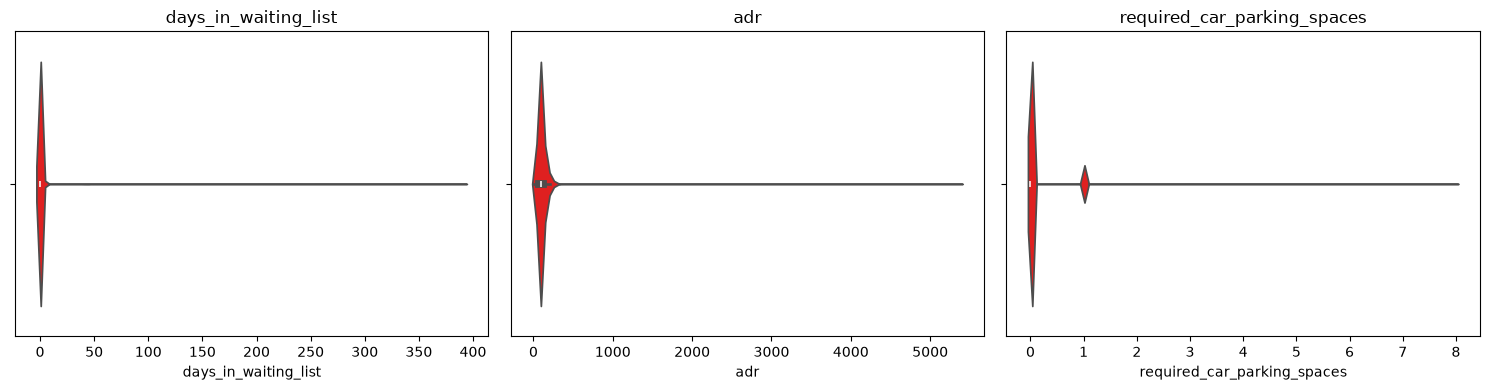

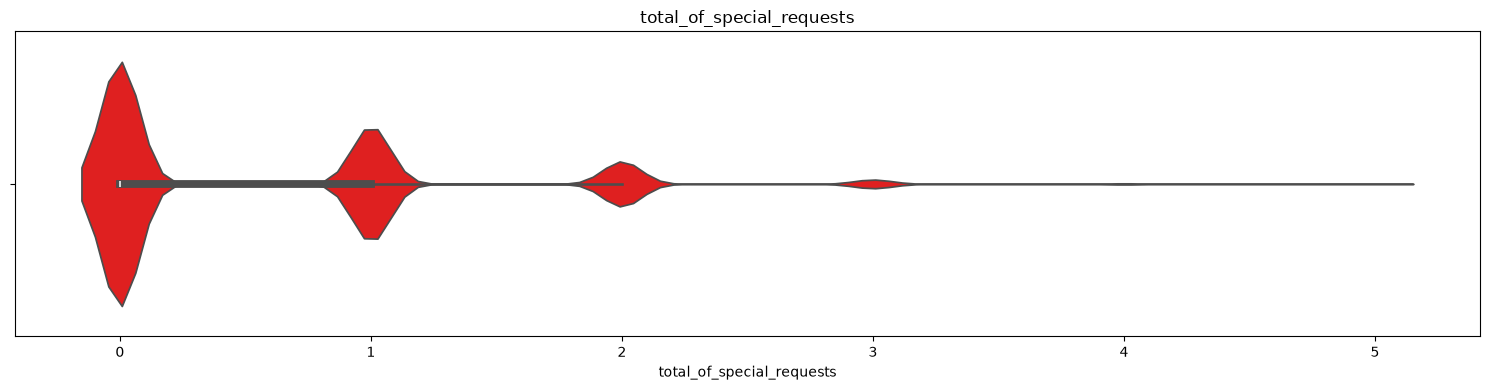

In [12]:
box_plt_cols = numerical_cols[1:]

n_cols = 3

for start in range(0, len(box_plt_cols), n_cols):
    cols = box_plt_cols[start:start + n_cols]

    fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))

    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, cols):
        sns.violinplot(x=df[col], color='red', ax=ax)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

    plt.close(fig)

### Outliers

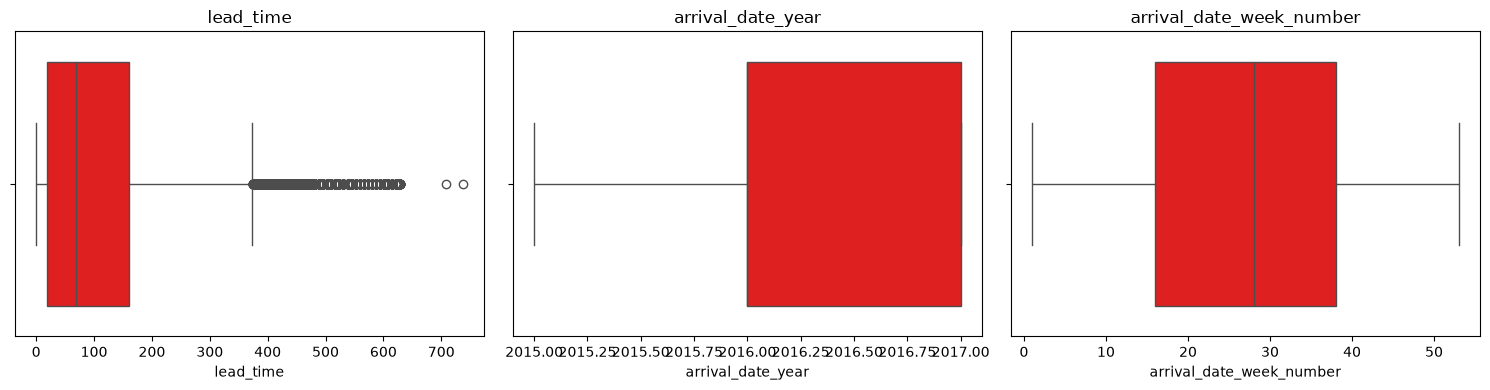

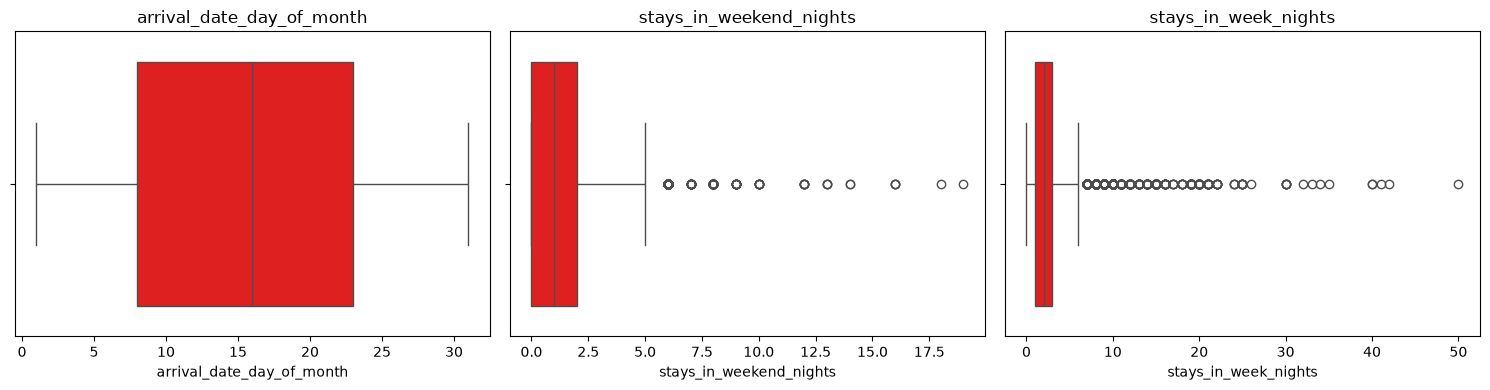

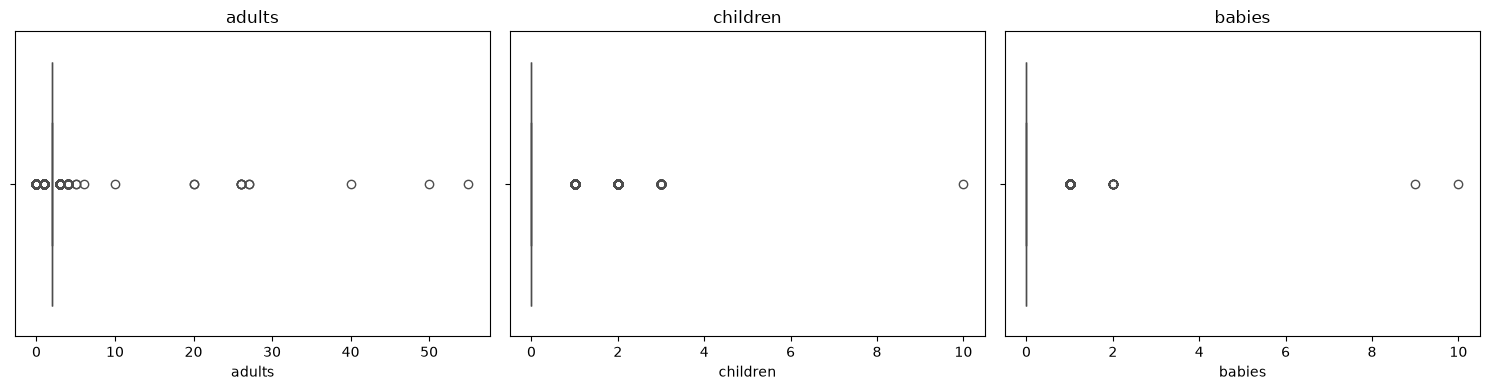

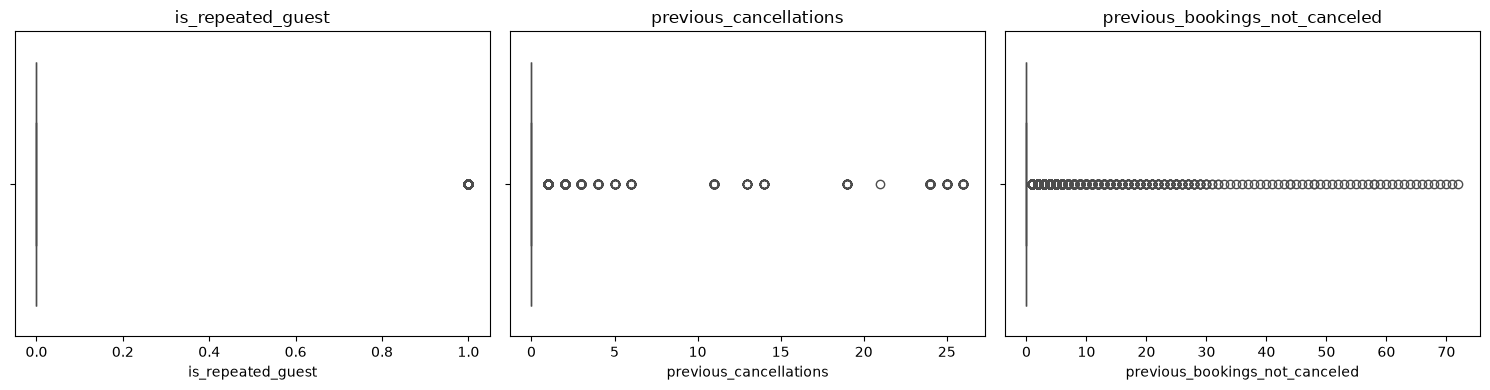

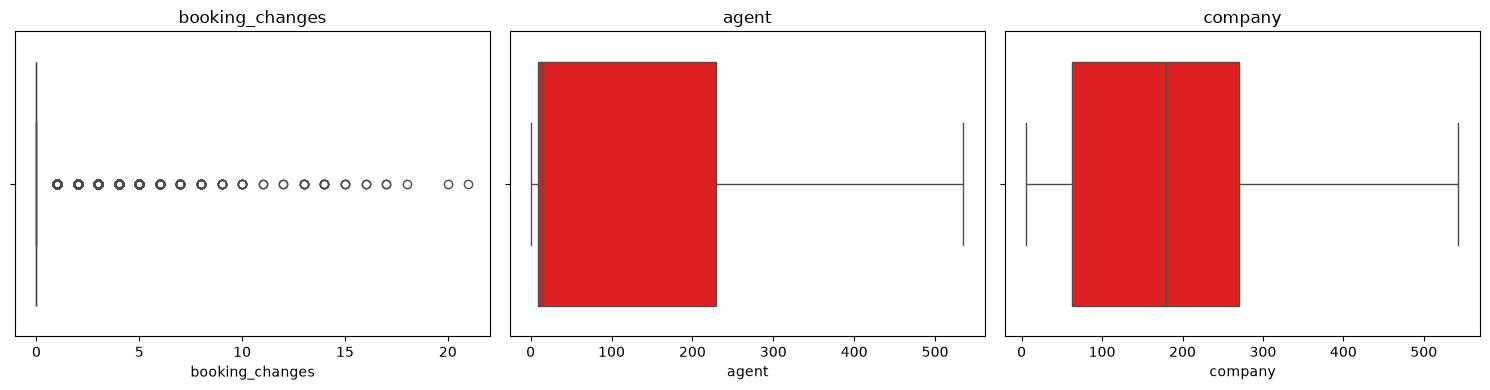

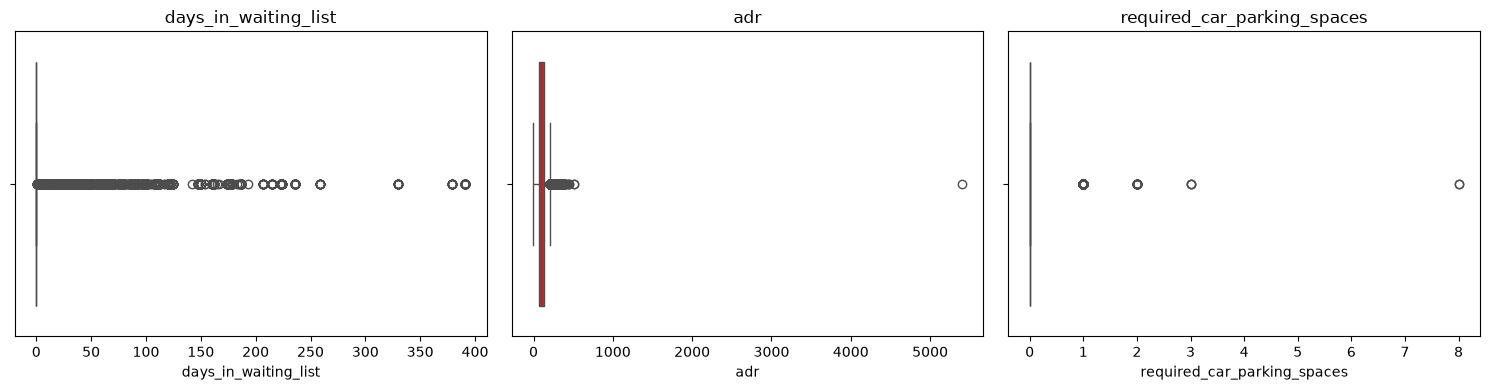

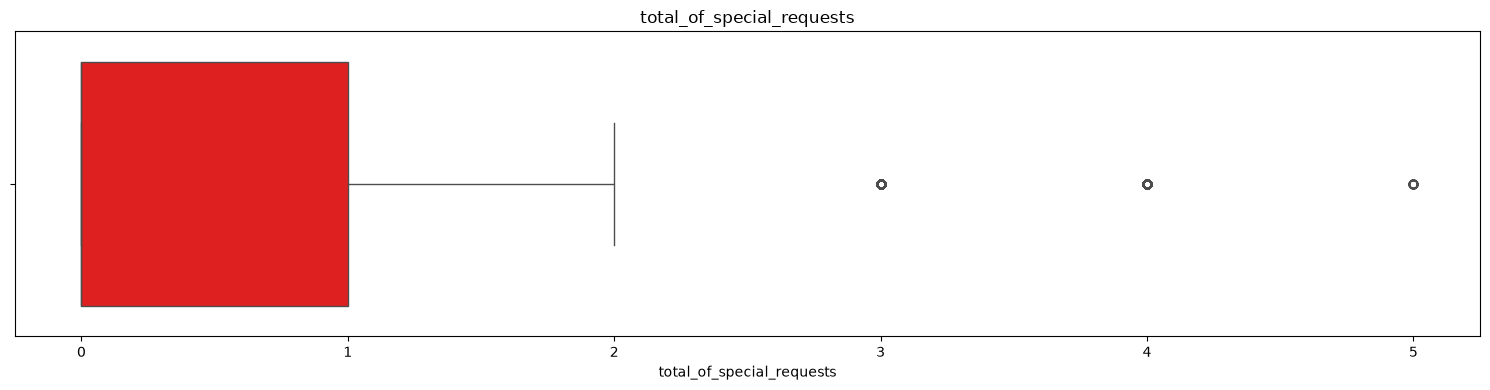

In [13]:
box_plt_cols = numerical_cols[1:]

n_cols = 3

for start in range(0, len(box_plt_cols), n_cols):
    cols = box_plt_cols[start:start + n_cols]

    fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))

    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, cols):
        sns.boxplot(x=df[col], color='red', ax=ax)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

    plt.close(fig)

## Data anomalies

In [14]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Zero guests

In [15]:
zero_guests = duckdb.sql("""
SELECT *
From df
WHERE adults <= 0 AND children <= 0 AND babies <= 0
""").df()

In [16]:
zero_guests.shape

(180, 32)

### Zero day stays

In [17]:
zero_day_stays = duckdb.sql("""
SELECT *
From df
WHERE stays_in_weekend_nights <= 0 AND stays_in_week_nights <= 0
""").df()

In [18]:
zero_day_stays.shape

(715, 32)

### Babies and children only

In [19]:
babies_only = duckdb.sql("""
SELECT *
From df
WHERE adults <= 0 AND children <= 0 AND babies > 0
""").df()

In [20]:
babies_only.shape

(0, 32)

### Children only

In [21]:
children_only = duckdb.sql("""
SELECT *
From df
WHERE adults <= 0 AND children > 0 AND babies <= 0
""").df()

In [22]:
children_only.shape

(220, 32)

### Zero guests + Zero day stays

In [23]:
zero_guests_and_zero_day_stays = duckdb.sql("""
SELECT *
From df
WHERE adults <= 0 AND children <= 0 AND babies <= 0 AND stays_in_weekend_nights <= 0 AND stays_in_week_nights <= 0
""").df()

In [24]:
zero_guests_and_zero_day_stays.shape

(70, 32)

## Class balance

In [25]:
print("Class distribution")
print(df['is_canceled'].value_counts())

Class distribution
is_canceled
0    75166
1    44224
Name: count, dtype: int64


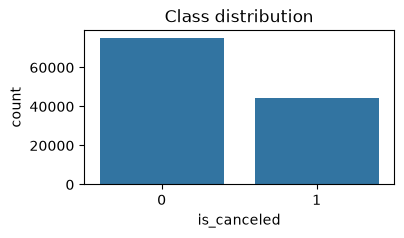

In [26]:
plt.figure(figsize=(4, 2))
sns.countplot(x=df['is_canceled'])
plt.title("Class distribution")
plt.show()